In [1]:
import os

path = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024"

items = os.listdir(path)
for item in items:
    print(item)


.99953958219384612061998297857947653707.json.swp
images
metadata
masks


In [7]:
import os

image_folder = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/images"
files = [f for f in os.listdir(image_folder) if f.endswith(".npz")]

# Print the first 5 file names
for f in files[:5]:
    print(f)

# Print total count
print(f"\nTotal image files: {len(files)}")


11620829065917056302623714571719433265.npz
14250050444401179523896463512599445624.npz
179676907984131951323580155265323083339.npz
173609540970239026681763962546839225953.npz
166335633480485949812226284872981999622.npz

Total image files: 163568


In [3]:
import numpy as np

file_path = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/images/11620829065917056302623714571719433265.npz"

# Load the .npz file
with np.load(file_path) as data:
    print("Keys in the .npz file:", data.files)
    
    if 'data' in data:
        print("Shape of 'data':", data['data'].shape)
    else:
        for key in data.files:
            print(f"Shape of '{key}':", data[key].shape)



Keys in the .npz file: ['data']
Shape of 'data': (1024, 1024)


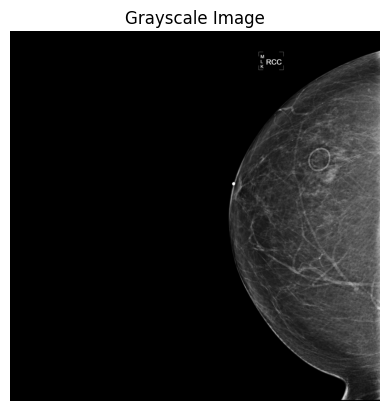

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Path to your .npz file
file_path = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/images/11620829065917056302623714571719433265.npz"

# Load and display
data = np.load(file_path)
image = data["data"]

plt.imshow(image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


In [6]:
import os

metadata_folder = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/metadata"
files = [f for f in os.listdir(metadata_folder) if f.endswith(".json")]

# Show the first 5 metadata files
for f in files[:5]:
    print(f)

print(f"\nTotal metadata files: {len(files)}")


188693894476289229233450436267581101590.json
241121076722351448350432238079384726123.json
17094743298291179203326834466551850093.json
189947137563287415551163390691437358497.json
227670955645247820376970241554089534780.json

Total metadata files: 163568


In [10]:
import os
import json

# === Single metadata file info ===
single_json_path = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/metadata/188693894476289229233450436267581101590.json"
with open(single_json_path, 'r') as f:
    metadata = json.load(f)

print(" Single metadata content:", metadata)
print(" Number of keys in single metadata file:", len(metadata))

# === Entire metadata dataset info ===
metadata_folder = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/metadata"
json_files = [f for f in os.listdir(metadata_folder) if f.endswith(".json")]

print(f"\n Total metadata JSON files in dataset: {len(json_files)}")


 Single metadata content: {'PatientID': 'DHUQ2OVG6EOG', 'View': 'medio-lateral oblique', 'WindowCenter': [2449.0, 2521.0, 2389.0], 'WindowWidth': [900.0, 750.0, 1050.0], 'WindowCenterWidthExplanation': ['NORMAL', 'HARDER', 'SOFTER'], 'ImagerPixelSpacing': [0.09409090909091, 0.09409090909091], 'ImageLaterality': 'R', 'coords': [870, 691, 958, 755], 'score': 0.0018872420769184828, 'label': 'NonCancer'}
 Number of keys in single metadata file: 10

 Total metadata JSON files in dataset: 163568


In [11]:
import os
import json
from collections import Counter

# Path to metadata folder
metadata_dir = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/metadata"

# Initialize label counter
label_counts = Counter()

# Iterate through each JSON file
for filename in os.listdir(metadata_dir):
    if filename.endswith(".json"):
        json_path = os.path.join(metadata_dir, filename)
        with open(json_path, 'r') as f:
            try:
                data = json.load(f)
                label = data.get("label", "Unknown")
                label_counts[label] += 1
            except Exception as e:
                print(f"Error reading {filename}: {e}")

# Print result
print("\n Label Distribution:")
for label, count in label_counts.items():
    print(f"• {label}: {count} samples")



 Label Distribution:
• NonCancer: 154238 samples
• PreIndexCancer: 1548 samples
• Unknown: 1979 samples
• IndexCancer: 5803 samples


In [12]:
import os
import json
from collections import Counter

# Metadata folder path
metadata_dir = "/raid/mpsych/OMAMA/2025/PLAYGROUND/cancer_classifier_1024/2d_resized_1024/metadata"

# Initialize counter
laterality_counts = Counter()

# Iterate and extract laterality
for filename in os.listdir(metadata_dir):
    if filename.endswith(".json"):
        json_path = os.path.join(metadata_dir, filename)
        with open(json_path, 'r') as f:
            try:
                data = json.load(f)
                laterality = data.get("ImageLaterality", "Unknown")
                laterality_counts[laterality] += 1
            except Exception as e:
                print(f"Error reading {filename}: {e}")

# Display results
print("\n🧭 ImageLaterality Distribution:")
for side, count in laterality_counts.items():
    print(f"• {side}: {count} images")



🧭 ImageLaterality Distribution:
• R: 82045 images
• L: 81523 images
